# Crypto Market Data Analysis

This notebook analyzes cryptocurrency market data collected from the CoinGecko API.

Workflow:
1. Load the dataset
2. Explore data structure
3. Clean missing values
4. Analyze market capitalization
5. Identify top gainers and losers
6. Visualize price movement
7. Generate simple volatility features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import requests
import pandas as pd

url = "https://api.coingecko.com/api/v3/coins/markets"

params = {
    "vs_currency": "usd",
    "order": "market_cap_desc",
    "per_page": 100,
    "page": 1,
    "sparkline": "false"
}

response = requests.get(url, params=params)
data = response.json()

df = pd.DataFrame(data)

columns = [
    "id",
    "symbol",
    "name",
    "current_price",
    "market_cap",
    "market_cap_rank",
    "total_volume",
    "high_24h",
    "low_24h",
    "price_change_24h",
    "price_change_percentage_24h",
    "circulating_supply",
    "ath",
    "atl",
    "last_updated"
]

df = df[columns]

df.to_csv("crypto_market.csv", index=False)

print(df.head())

            id symbol      name  current_price     market_cap  \
0      bitcoin    btc   Bitcoin       74635.00  1493263629515   
1     ethereum    eth  Ethereum        2338.36   282287646603   
2       tether   usdt    Tether           1.00   184083907972   
3       ripple    xrp       XRP           1.53    93954231921   
4  binancecoin    bnb       BNB         673.62    91857714270   

   market_cap_rank  total_volume  high_24h      low_24h  price_change_24h  \
0                1  5.281892e+10  75937.00  73530.00000        286.470000   
1                2  2.900760e+10   2377.64   2299.90000        -12.234578   
2                3  8.834414e+10      1.00      0.99993          0.000042   
3                4  4.619302e+09      1.60      1.50000          0.004125   
4                5  1.243587e+09    685.48    664.27000         -5.006515   

   price_change_percentage_24h  circulating_supply        ath        atl  \
0                      0.38531        2.000304e+07  126080.00  67.8100

In [3]:
import pandas as pd

df = pd.read_csv("crypto_market.csv")
df.head()

,id,symbol,name,current_price,market_cap,market_cap_rank,total_volume,high_24h,low_24h,price_change_24h,price_change_percentage_24h,circulating_supply,ath,atl,last_updated
0,bitcoin,btc,Bitcoin,74635.00,1493263629515,1,5.281892e+10,75937.00,73530.00000,286.470000,0.38531,2.000304e+07,126080.00,67.810000,2026-03-17T21:24:53.514Z
1,ethereum,eth,Ethereum,2338.36,282287646603,2,2.900760e+10,2377.64,2299.90000,-12.234578,-0.52049,1.206919e+08,4946.05,0.432979,2026-03-17T21:24:53.934Z
2,tether,usdt,Tether,1.00,184083907972,3,8.834414e+10,1.00,0.99993,0.000042,0.00417,1.840709e+11,1.32,0.572521,2026-03-17T21:24:54.442Z
3,ripple,xrp,XRP,1.53,93954231921,4,4.619302e+09,1.60,1.50000,0.004125,0.26958,6.122783e+10,3.65,0.002686,2026-03-17T21:24:54.318Z
4,binancecoin,bnb,BNB,673.62,91857714270,5,1.243587e+09,685.48,664.27000,-5.006515,-0.73774,1.363578e+08,1369.99,0.039818,2026-03-17T21:24:53.661Z


In [4]:
df.shape

(100, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           100 non-null    object 
 1   symbol                       100 non-null    object 
 2   name                         100 non-null    object 
 3   current_price                100 non-null    float64
 4   market_cap                   100 non-null    int64  
 5   market_cap_rank              100 non-null    int64  
 6   total_volume                 100 non-null    float64
 7   high_24h                     99 non-null     float64
 8   low_24h                      99 non-null     float64
 9   price_change_24h             99 non-null     float64
 10  price_change_percentage_24h  99 non-null     float64
 11  circulating_supply           100 non-null    float64
 12  ath                          100 non-null    float64
 13  atl                  

In [6]:
df.describe()

,current_price,market_cap,market_cap_rank,total_volume,high_24h,low_24h,price_change_24h,price_change_percentage_24h,circulating_supply,ath,atl
count,100.000000,1.000000e+02,100.000000,1.000000e+02,99.000000,99.000000,99.000000,99.000000,1.000000e+02,100.000000,1.000000e+02
mean,897.952043,2.569350e+10,50.500000,2.081685e+09,921.692138,894.637270,2.651702,0.260298,2.016876e+13,1560.752618,3.220003e+01
std,7484.581565,1.526370e+11,29.011492,1.065270e+10,7652.700626,7411.421756,28.866897,6.304292,1.159627e+14,12620.362022,2.003323e+02
min,0.000002,4.945072e+08,1.000000,0.000000e+00,0.000002,0.000002,-12.234578,-9.087190,5.011504e+05,0.000004,5.636600e-11
25%,0.169708,8.556721e+08,25.750000,1.294800e+07,0.166474,0.156662,-0.012236,-1.080485,5.420305e+08,1.000750,2.570560e-02
50%,0.999956,1.727235e+09,50.500000,6.757022e+07,1.001000,0.999371,-0.000132,-0.144440,1.750134e+09,2.070000,3.989125e-01
75%,3.765000,4.340571e+09,75.250000,2.267766e+08,4.060000,3.815000,0.000455,0.078010,1.744014e+10,44.110000,9.695720e-01
max,74635.000000,1.493264e+12,100.000000,8.834414e+10,75937.000000,73530.000000,286.470000,56.816900,9.165331e+14,126080.000000,1.447840e+03


In [7]:
df.isnull().sum()

,0
id,0
symbol,0
name,0
current_price,0
market_cap,0
market_cap_rank,0
total_volume,0
high_24h,1
low_24h,1
price_change_24h,1


In [8]:
key_columns = [
    "current_price",
    "market_cap",
    "total_volume",
    "price_change_percentage_24h"
]

df = df.dropna(subset=key_columns)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99 entries, 0 to 99
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           99 non-null     object 
 1   symbol                       99 non-null     object 
 2   name                         99 non-null     object 
 3   current_price                99 non-null     float64
 4   market_cap                   99 non-null     int64  
 5   market_cap_rank              99 non-null     int64  
 6   total_volume                 99 non-null     float64
 7   high_24h                     99 non-null     float64
 8   low_24h                      99 non-null     float64
 9   price_change_24h             99 non-null     float64
 10  price_change_percentage_24h  99 non-null     float64
 11  circulating_supply           99 non-null     float64
 12  ath                          99 non-null     float64
 13  atl                        

In [10]:
top_market_cap = df.sort_values(by="market_cap", ascending=False).head(10)
top_market_cap[["name", "symbol", "current_price", "market_cap", "total_volume"]]

,name,symbol,current_price,market_cap,total_volume
0,Bitcoin,btc,74635.000000,1493263629515,5.281892e+10
1,Ethereum,eth,2338.360000,282287646603,2.900760e+10
2,Tether,usdt,1.000000,184083907972,8.834414e+10
3,XRP,xrp,1.530000,93954231921,4.619302e+09
4,BNB,bnb,673.620000,91857714270,1.243587e+09
5,USDC,usdc,0.999847,79614065944,1.344831e+10
6,Solana,sol,95.180000,54393821089,4.392092e+09
7,TRON,trx,0.305879,28981433550,6.140217e+08
8,Figure Heloc,figr_heloc,1.032000,16345286289,3.883480e+07
9,Dogecoin,doge,0.100949,15491566672,1.537043e+09


In [11]:
top_gainers = df.sort_values(by="price_change_percentage_24h", ascending=False).head(10)
top_gainers[["name", "symbol", "current_price", "price_change_percentage_24h"]]

,name,symbol,current_price,price_change_percentage_24h
96,Siren,siren,0.718841,56.81690
32,MemeCore,m,1.890000,13.26923
70,Kaspa,kas,0.036523,9.29098
44,Aster,aster,0.773964,5.45163
66,Quant,qnt,71.450000,4.68781
88,Jupiter,jup,0.176344,3.81563
13,Hyperliquid,hype,41.990000,3.53907
7,TRON,trx,0.305879,3.47285
84,Provenance Blockchain,hash,0.012915,2.52675
53,HTX DAO,htx,0.000002,2.19448


In [12]:
top_losers = df.sort_values(by="price_change_percentage_24h", ascending=True).head(10)
top_losers[["name", "symbol", "current_price", "price_change_percentage_24h"]]

,name,symbol,current_price,price_change_percentage_24h
49,Pi Network,pi,0.178615,-9.08719
51,Pepe,pepe,0.000004,-6.40303
74,Official Trump,trump,3.680000,-5.32436
95,Artificial Superintelligence Alliance,fet,0.238885,-4.75001
50,Sky,sky,0.074218,-4.49612
34,World Liberty Financial,wlfi,0.102662,-3.96404
72,Render,render,1.830000,-3.66683
39,Uniswap,uni,4.020000,-3.39057
82,Filecoin,fil,0.975785,-2.68043
29,Sui,sui,1.038000,-2.58861


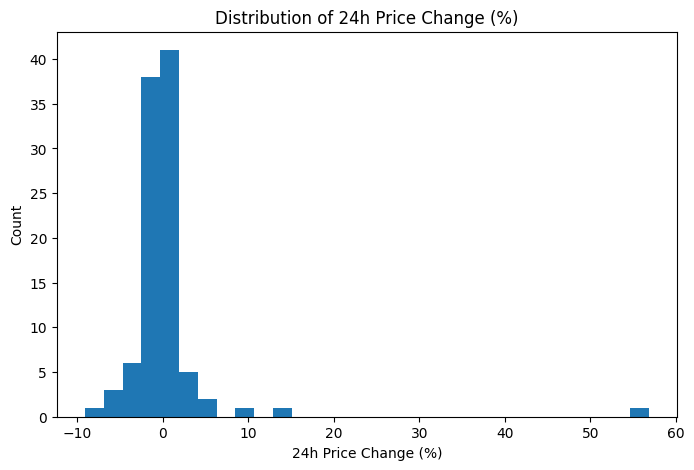

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["price_change_percentage_24h"], bins=30)
plt.title("Distribution of 24h Price Change (%)")
plt.xlabel("24h Price Change (%)")
plt.ylabel("Count")
plt.show()

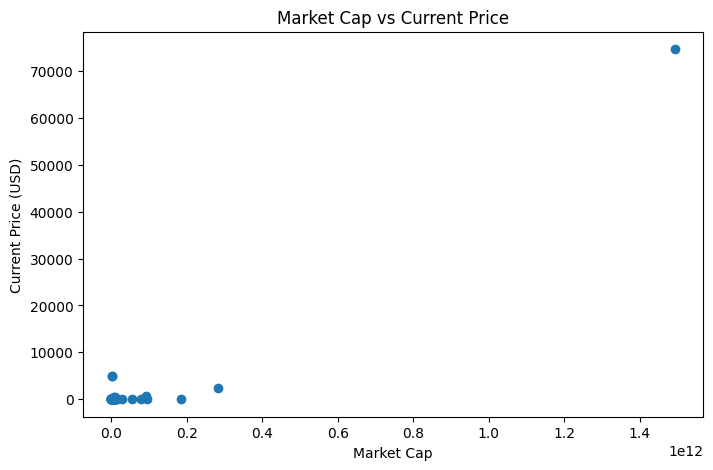

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(df["market_cap"], df["current_price"])
plt.title("Market Cap vs Current Price")
plt.xlabel("Market Cap")
plt.ylabel("Current Price (USD)")
plt.show()

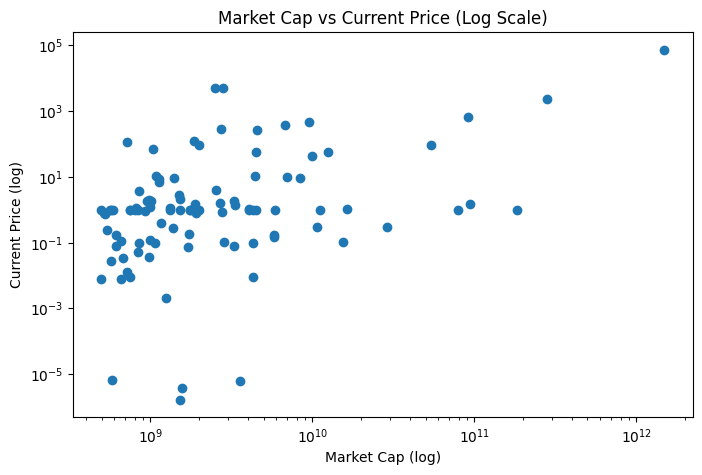

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(df["market_cap"], df["current_price"])
plt.xscale("log")
plt.yscale("log")
plt.title("Market Cap vs Current Price (Log Scale)")
plt.xlabel("Market Cap (log)")
plt.ylabel("Current Price (log)")
plt.show()

In [16]:
import numpy as np

df["high_volatility"] = np.where(df["price_change_percentage_24h"].abs() > 10, 1, 0)
df[["name", "price_change_percentage_24h", "high_volatility"]].head()

,name,price_change_percentage_24h,high_volatility
0,Bitcoin,0.38531,0
1,Ethereum,-0.52049,0
2,Tether,0.00417,0
3,XRP,0.26958,0
4,BNB,-0.73774,0


In [17]:
df["high_volatility"].value_counts()

,count
high_volatility,
0,97
1,2


## Key Insights

1. A small number of large cryptocurrencies dominate market capitalization.
2. Smaller coins tend to show larger 24-hour percentage swings.
3. Trading volume is concentrated among a few major assets.
4. Log-scale visualization is more useful for comparing cryptocurrencies with very different sizes.
5. This project demonstrates API-based data collection, cleaning, storage, and exploratory analysis.

## Project Summary

This project demonstrates a simple data workflow:

- Collect cryptocurrency market data from an API
- Store the data as a CSV dataset
- Perform exploratory data analysis
- Visualize market structure and volatility

Although this project does not build a predictive model, it focuses on data ingestion and analysis, which are key parts of real-world data science workflows.